In [1]:
import scanpy as sc
from pathlib import Path

In [2]:
INDIR = Path.home()/'project/crc-pm/result/latest.h5ad'
adata = sc.read_h5ad(INDIR)
adata_imu = adata[adata.obs['Compartment'] == 'Immune']
del adata

In [3]:
sc.pp.neighbors(
    adata_imu,
    use_rep="X_scVI",
    n_neighbors=20,
    metric="cosine",
    random_state=42,
)

sc.tl.umap(
    adata_imu,
    min_dist=0.25,
    random_state=2026,)

# use different res
leiden_res = [0.25, 0.5, 1.0,1.5]
for i in leiden_res:
    sc.tl.leiden(adata_imu, key_added=f"leiden_res{i}", resolution=i, flavor="igraph", n_iterations=2)


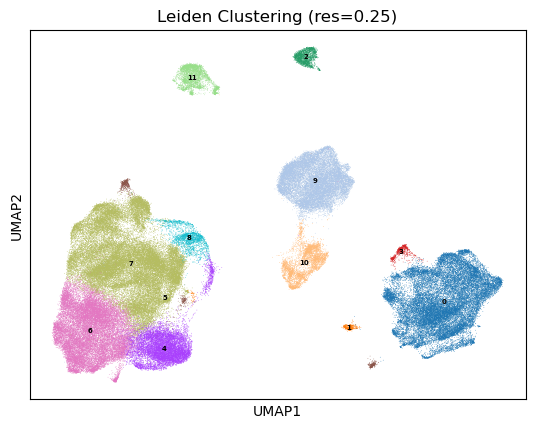

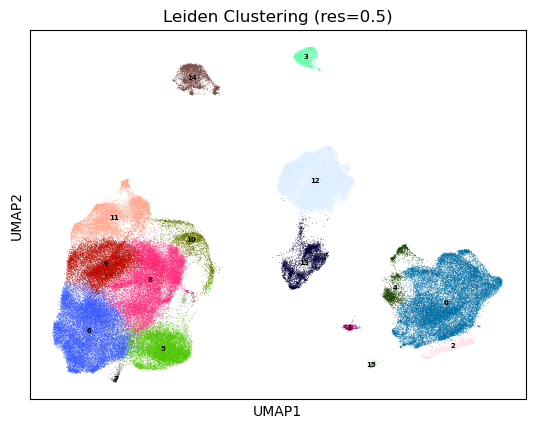

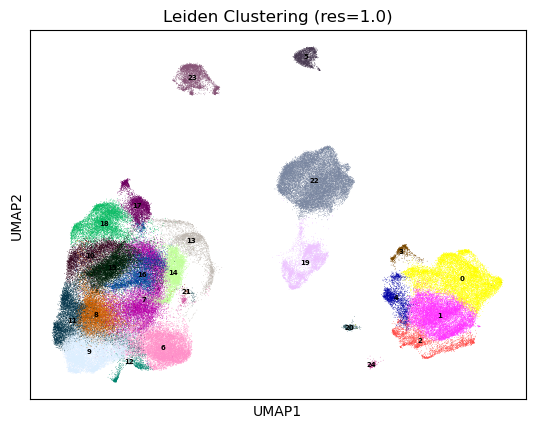

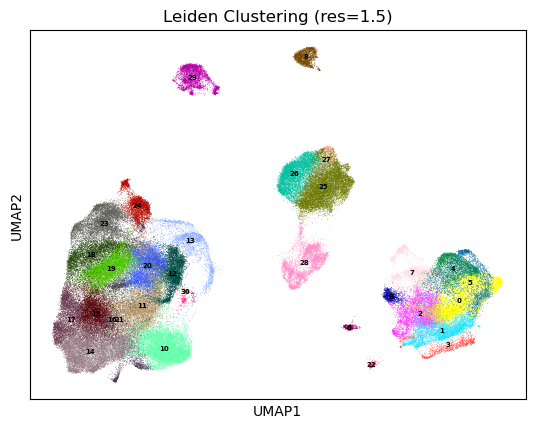

In [10]:
for i in leiden_res:
    sc.pl.umap(
        adata_imu,
        color=f"leiden_res{i}",
        legend_loc="on data",
        title=f"Leiden Clustering (res={i})",
        legend_fontsize = 5,
    )

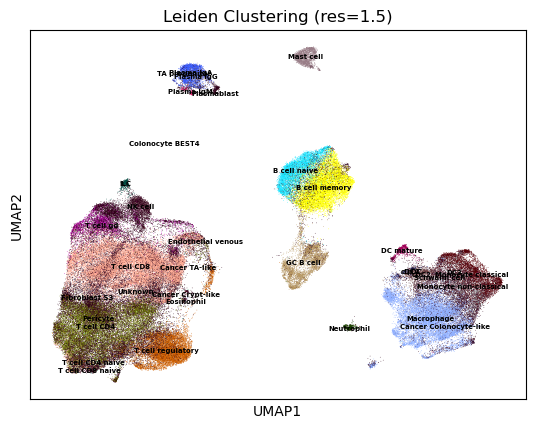

In [6]:
sc.pl.umap(
        adata_imu,
        color='scANVI_CellType',
        legend_loc="on data",
        legend_fontsize = 5,
        title=f"Leiden Clustering (res={i})",
    )

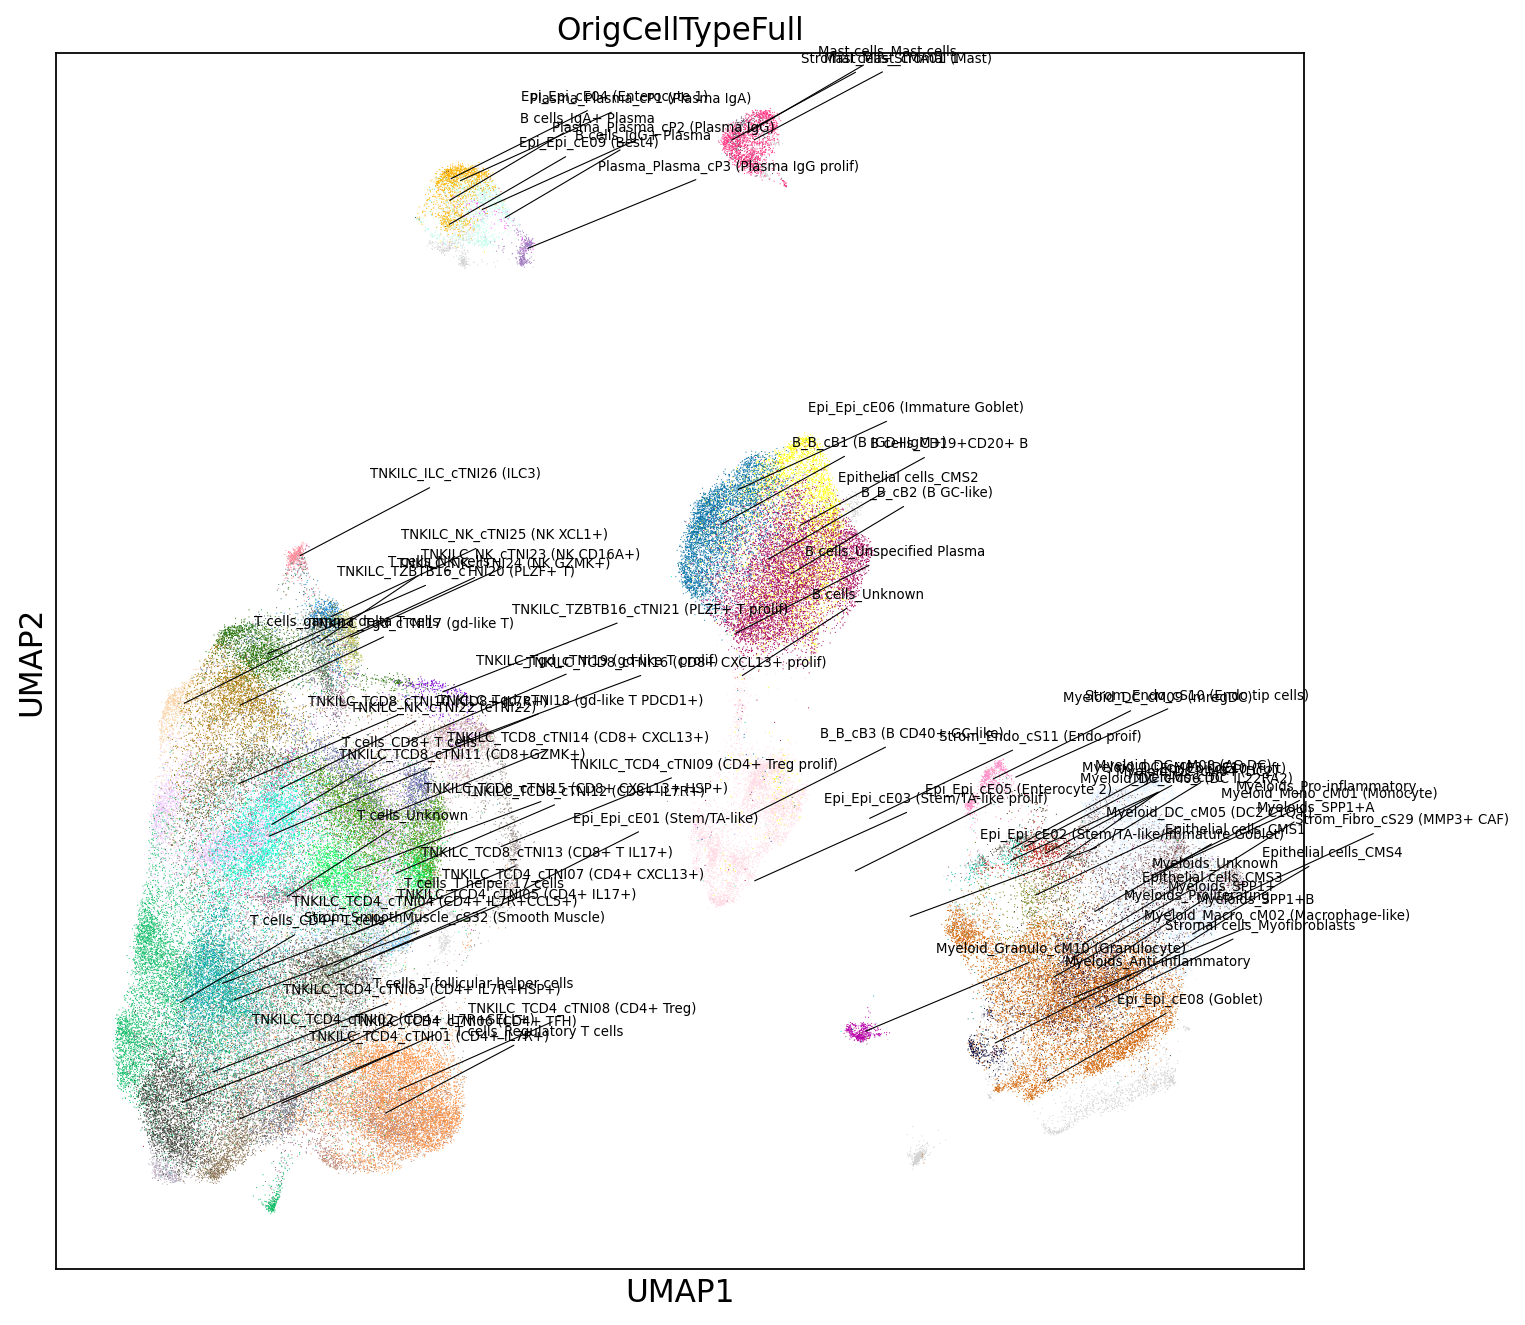

In [33]:
sc.set_figure_params(figsize=(10, 10))
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

ax = sc.pl.umap(
    adata_imu,
    color="OrigCellTypeFull",
    legend_loc=None,
    show=False,
)

umap = adata_imu.obsm["X_umap"]
groups = adata_imu.obs["OrigCellTypeFull"]

for celltype in groups.cat.categories:
    mask = groups == celltype

    # 亚群中心
    x = np.median(umap[mask, 0])
    y = np.median(umap[mask, 1])

    ax.annotate(
        celltype,
        xy=(x, y),
        xytext=(x + 1.5, y + 1.5),
        fontsize=6,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.5,
        ),
    )

plt.show()

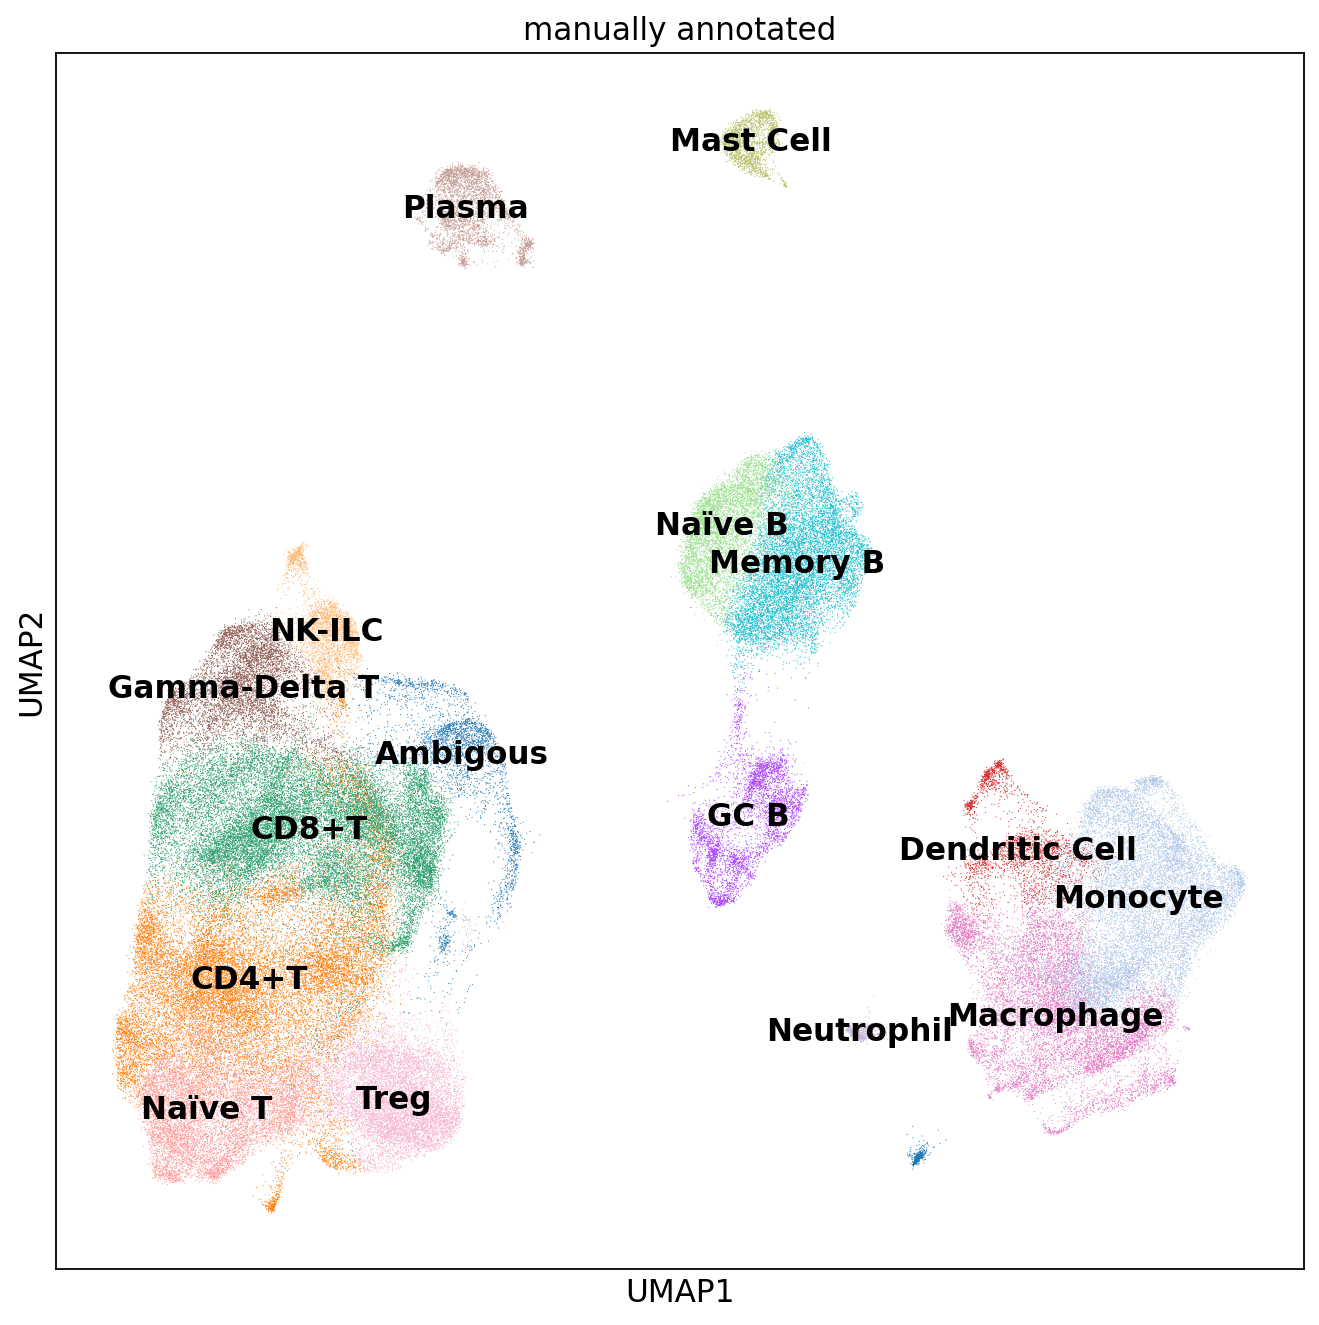

In [44]:
dict_res1_5 = {
    '0': 'Monocyte',
    '1' : 'Macrophage',
    '2' : 'Macrophage',
    '3' : 'Macrophage',
    '4' : 'Monocyte',
    '5' : 'Monocyte',
    '6' : 'Neutrophil',
    '7' : 'Dendritic Cell',
    '8' : 'Mast Cell',
    '9' : 'Macrophage',
    '10' : 'Treg',
    '11' : 'CD4+T',
    '12' : 'CD8+T',
    '13' : 'Ambigous',
    '14' : 'Naïve T',
    '15' : 'CD4+T',
    '16' : 'CD4+T',
    '17' : 'CD4+T',
    '18' : 'CD8+T',
    '19' : 'CD8+T',
    '20' : 'CD8+T',
    '21' : 'CD4+T',
    '22' : 'Ambigous',
    '23' : 'Gamma-Delta T',
    '24' : 'NK-ILC',
    '25' : 'Memory B',
    '26' : 'Naïve B',
    '27' : 'Memory B',
    '28' : 'GC B',
    '29' : 'Plasma',
    '30' : 'Ambigous',
}
adata_imu.obs['man_anno'] = adata_imu.obs['leiden_res1.5'].map(dict_res1_5)
sc.pl.umap(
        adata_imu,
        color='man_anno',
        legend_loc="on data",
        title="manually annotated",
    )